Initializing Super-Model Ensemble on cuda
Loading Model 1: ResNet-18 (Texture Expert)
Loading Model 2: ViT-B/16 (Context Expert)...
Fusing Predictions...


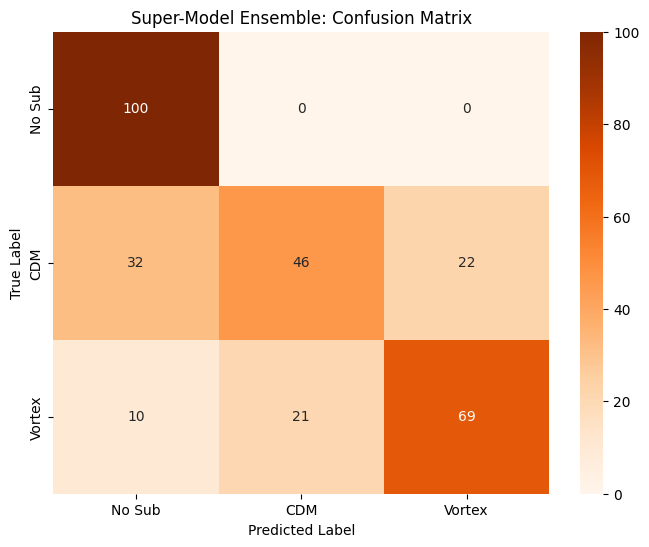


 ENSEMBLE FINAL REPORT:
              precision    recall  f1-score   support

      No Sub       0.70      1.00      0.83       100
         CDM       0.69      0.46      0.55       100
      Vortex       0.76      0.69      0.72       100

    accuracy                           0.72       300
   macro avg       0.72      0.72      0.70       300
weighted avg       0.72      0.72      0.70       300

Running Test-Time Augmentation (TTA)... This evaluates 4x the data!


TTA Evaluation: 100%|██████████| 10/10 [00:18<00:00,  1.81s/it]


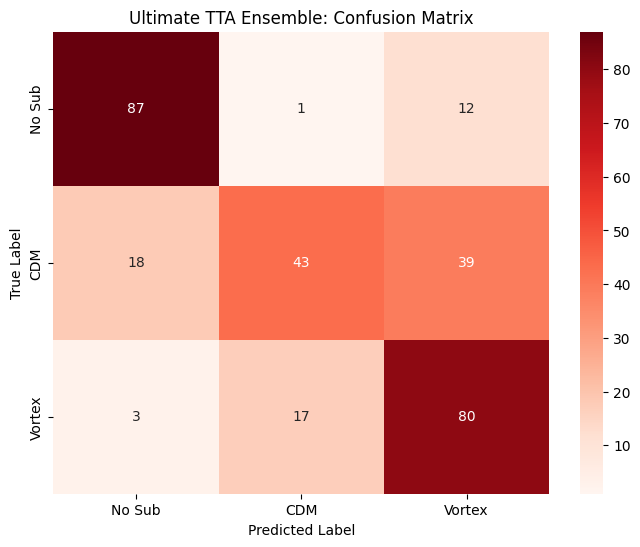


 ULTIMATE TTA FINAL REPORT:
              precision    recall  f1-score   support

      No Sub       0.81      0.87      0.84       100
         CDM       0.70      0.43      0.53       100
      Vortex       0.61      0.80      0.69       100

    accuracy                           0.70       300
   macro avg       0.71      0.70      0.69       300
weighted avg       0.71      0.70      0.69       300



In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
import pandas as pd
from PIL import Image
import os
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_dir = "/content/drive/My Drive/DeepLense_GSoC_Data"
print(f"Initializing Super-Model Ensemble on {device}")

class DeepLenseDatasetEnsemble(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform
        self.class_map = {'no_sub': 0, 'cdm': 1, 'vortex': 2}
    def __len__(self): return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.root_dir, row['class'], row['filename'])
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, self.class_map[row['class']]

vit_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

df = pd.read_csv(os.path.join(base_dir, "metadata.csv"))
from sklearn.model_selection import train_test_split
_, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['class'])
val_loader = DataLoader(DeepLenseDatasetEnsemble(val_df, base_dir, transform=vit_transform), batch_size=32, shuffle=False)

print("Loading Model 1: ResNet-18 (Texture Expert)")
resnet = models.resnet18(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, 3)
resnet.load_state_dict(torch.load(os.path.join(base_dir, "resnet18_robust.pth"), map_location=device))
resnet = resnet.to(device)
resnet.eval()

print("Loading Model 2: ViT-B/16 (Context Expert)...")
vit = models.vit_b_16(weights=None)
vit.heads.head = nn.Linear(vit.heads.head.in_features, 3)
vit.load_state_dict(torch.load(os.path.join(base_dir, "vit_b_16_champion.pth"), map_location=device))
vit = vit.to(device)
vit.eval()

all_preds_ensemble = []
all_labels = []

print("Fusing Predictions...")
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        
        vit_outputs = vit(images)
        vit_probs = F.softmax(vit_outputs, dim=1)
        
        images_64 = F.interpolate(images, size=(64, 64), mode='bilinear', align_corners=False)
        resnet_outputs = resnet(images_64)
        resnet_probs = F.softmax(resnet_outputs, dim=1)
        
        ensemble_probs = (vit_probs + resnet_probs) / 2.0
        _, predicted = torch.max(ensemble_probs, 1)
        
        all_preds_ensemble.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

classes = ['No Sub', 'CDM', 'Vortex']
cm = confusion_matrix(all_labels, all_preds_ensemble)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes)
plt.title('Super-Model Ensemble: Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
assets_dir = os.path.join(base_dir, "assets")
os.makedirs(assets_dir, exist_ok=True)
plt.savefig(os.path.join(assets_dir, "ensemble_cm.png"), bbox_inches='tight', dpi=300)
plt.show()

print("\n ENSEMBLE FINAL REPORT:")
print(classification_report(all_labels, all_preds_ensemble, target_names=classes))

# TEST-TIME AUGMENTATION (TTA) 
import torchvision.transforms.functional as TF
from tqdm import tqdm

all_preds_tta = []
all_labels_tta = []
rotations = [0, 90, 180, 270] 

print("Running Test-Time Augmentation (TTA)... This evaluates 4x the data!")
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="TTA Evaluation"):
        images, labels = images.to(device), labels.to(device)
        batch_size = images.size(0)
        
        accumulated_probs = torch.zeros((batch_size, 3)).to(device)
        
        for angle in rotations:
            rotated_images = TF.rotate(images, angle)
            
            vit_outputs = vit(rotated_images)
            vit_probs = F.softmax(vit_outputs, dim=1)
            
            images_64 = F.interpolate(rotated_images, size=(64, 64), mode='bilinear', align_corners=False)
            resnet_outputs = resnet(images_64)
            resnet_probs = F.softmax(resnet_outputs, dim=1)
            
            current_rotation_probs = (vit_probs + resnet_probs) / 2.0
            accumulated_probs += current_rotation_probs
            
        final_probs = accumulated_probs / len(rotations)
        _, predicted = torch.max(final_probs, 1)
        
        all_preds_tta.extend(predicted.cpu().numpy())
        all_labels_tta.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels_tta, all_preds_tta)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=classes, yticklabels=classes)
plt.title('Ultimate TTA Ensemble: Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
assets_dir = os.path.join(base_dir, "assets")
os.makedirs(assets_dir, exist_ok=True)
plt.savefig(os.path.join(assets_dir, "tta_diagnostic.png"), bbox_inches='tight', dpi=300)
plt.show()

print("\n ULTIMATE TTA FINAL REPORT:")
print(classification_report(all_labels_tta, all_preds_tta, target_names=classes))